# 04 — Baselines and rolling-origin evaluation

This notebook evaluates the expanded Dataset B panel selected in notebook 03. Every forecast is generated at an explicit origin using only values available by that origin. Seasonal naive, last value, and per-series Ridge are compared on the same complete rolling-origin windows, so missing observations cannot give one model an unfair advantage.

### What the setup code does and why

This code imports the data, plotting, and modelling tools; finds the project folders; loads the shared evaluation settings; and fixes the random seed. We need this so every later cell uses the same horizons, lag-window length, paths, and repeatable settings.

In [ ]:
# mount Google Drive and set the working directory to the project path
from google.colab import drive
drive.mount("/content/drive")
import os
os.chdir("/content/drive/MyDrive/JobAI")  # the project path
os.environ["JOBAI_REPO"] = "/content/drive/MyDrive/JobAI"

In [15]:
import hashlib, json, math, os
from pathlib import Path
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import yaml
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def _find_repo():
    env = os.environ.get("JOBAI_REPO")
    if env:
        return Path(env).resolve()
    p = Path.cwd().resolve()
    for candidate in (p, *p.parents):
        if (candidate / "configs" / "eval.yaml").is_file():
            return candidate
    return p

REPO = _find_repo()
PRO = REPO / "data" / "processed"
REPORTS = REPO / "reports"
FIGURES = REPORTS / "figures"
REPORTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
CFG = yaml.safe_load((REPO / "configs" / "eval.yaml").read_text())
HORIZONS = [int(h) for h in CFG["horizons"]]
WINDOW = int(CFG["feature_window_quarters"])
SEED = int(CFG["seed"])
np.random.seed(SEED)
print("repo:", REPO)
print("horizons:", HORIZONS, "window:", WINDOW)

repo: /Users/Alan/Documents/Study/MLProject-JobAI
horizons: [1, 2, 4] window: 8


## Load the selected panel series

Read the panel targets chosen in notebook 03, load each large normalized table only once, and then reconstruct every selected occupation or industry series from its saved dimension signature.

### Summarize forecast accuracy

This code converts the individual prediction errors into MAE, RMSE, MASE, and sMAPE. It first measures every series separately and then averages across series, so a large or unusually complete series cannot dominate the panel result.

In [16]:
selection_path = PRO / "selected_series.csv"
assert selection_path.is_file(), "Run notebook 03 first"
selection = pd.read_csv(selection_path)
selected_mask = selection["selected"].astype(str).str.lower().eq("true")
panel_rows = selection[(selection["role"] == "panel_target") & selected_mask].copy()
assert not panel_rows.empty, "No selected panel targets found; run notebook 03 first"

def quarter_ordinal(q):
    return int(q[:4]) * 4 + int(q[-1]) - 1

series_data = {}
for table_id, selected_table in panel_rows.groupby("table_id", sort=True):
    normalized_path = PRO / f"{table_id}__normalized.csv"
    assert normalized_path.is_file(), f"Missing normalized table: {normalized_path.name}"
    table_frame = pd.read_csv(normalized_path, low_memory=False)
    first_dims = json.loads(selected_table.iloc[0]["dimensions_json"])
    dimension_cols = list(first_dims)
    selected_lookup = {}
    for row in selected_table.itertuples(index=False):
        dims = json.loads(row.dimensions_json)
        signature = tuple(str(dims[column]) for column in dimension_cols)
        selected_lookup[signature] = row.series_id
    grouped = table_frame.groupby(dimension_cols, dropna=False, sort=False)
    for group_key, frame in grouped:
        if not isinstance(group_key, tuple):
            group_key = (group_key,)
        signature = tuple(str(value) for value in group_key)
        series_id = selected_lookup.get(signature)
        if series_id is None:
            continue
        frame = frame[["timeperiod_q", "value"]].copy()
        frame["value"] = pd.to_numeric(frame["value"], errors="coerce")
        frame["quarter_index"] = frame["timeperiod_q"].map(quarter_ordinal)
        frame = frame.sort_values("quarter_index").reset_index(drop=True)
        assert frame["timeperiod_q"].is_unique, f"Duplicate quarter: {series_id}"
        assert np.diff(frame["quarter_index"]).tolist() == [1] * (len(frame) - 1), f"Panel series has a time gap: {series_id}"
        series_data[series_id] = {"table_id": table_id, "frame": frame}
assert len(series_data) == len(panel_rows), f"Loaded {len(series_data)} of {len(panel_rows)} selected panel series"
print("panel series loaded:", len(series_data))

panel series loaded: 1679


## Expanding-window forecasts

For a forecast made at origin `t`, Ridge training examples are restricted to complete lag windows whose target quarter is no later than `t`. The evaluation keeps an origin only when the current lag window, target, seasonal reference, and last value are all observed. Seasonal naive predicts `y[t+h-4]`, which is available at the origin for the configured horizons.

### Save the baseline evidence

This code saves every prediction, the per-series metrics, and the overall summary. It also writes a manifest with checksums and experiment settings, giving later notebooks a permanent, traceable baseline report instead of relying on values displayed only in memory.

In [17]:
splits = CFG["splits"]

def split_for_origin(q):
    if splits["val_start"] <= q <= splits["val_end"]:
        return "validation"
    if splits["test_start"] <= q <= splits["test_end"]:
        return "test"
    return None

prediction_rows = []
for series_id, info in series_data.items():
    frame = info["frame"]
    quarters = frame["timeperiod_q"].tolist()
    values = frame["value"].to_numpy(dtype=float)
    for origin_idx in range(WINDOW - 1, len(values)):
        origin = quarters[origin_idx]
        split = split_for_origin(origin)
        if split is None:
            continue
        history = values[:origin_idx + 1]
        seasonal_pairs = np.isfinite(history[4:]) & np.isfinite(history[:-4])
        seasonal_diffs = np.abs(history[4:][seasonal_pairs] - history[:-4][seasonal_pairs])
        mase_scale = float(np.mean(seasonal_diffs)) if len(seasonal_diffs) else np.nan
        if not np.isfinite(mase_scale) or mase_scale <= 0:
            continue
        for horizon in HORIZONS:
            target_idx = origin_idx + horizon
            if target_idx >= len(values):
                continue
            seasonal_idx = origin_idx + horizon - 4
            current_window = values[origin_idx - WINDOW + 1:origin_idx + 1]
            required_values = np.concatenate([current_window, [values[target_idx], values[seasonal_idx], values[origin_idx]]])
            if not np.isfinite(required_values).all():
                continue
            y_true = float(values[target_idx])
            forecasts = {
                "last_value": float(values[origin_idx]),
                "seasonal_naive": float(values[seasonal_idx]),
            }
            X_train, y_train = [], []
            latest_train_target = None
            for train_origin in range(WINDOW - 1, origin_idx - horizon + 1):
                train_target = train_origin + horizon
                assert train_target <= origin_idx
                train_window = values[train_origin - WINDOW + 1:train_origin + 1]
                train_value = values[train_target]
                if not np.isfinite(train_window).all() or not np.isfinite(train_value):
                    continue
                X_train.append(train_window)
                y_train.append(train_value)
                latest_train_target = train_target
            if len(X_train) < 10:
                continue
            ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
            ridge.fit(np.asarray(X_train), np.asarray(y_train))
            forecasts["ridge"] = float(ridge.predict(values[origin_idx - WINDOW + 1:origin_idx + 1].reshape(1, -1))[0])
            for model, y_pred in forecasts.items():
                abs_error = abs(y_true - y_pred)
                denom = (abs(y_true) + abs(y_pred)) / 2.0
                prediction_rows.append({
                    "table_id": info["table_id"], "series_id": series_id, "split": split,
                    "model": model, "horizon_q": horizon, "origin_quarter": origin,
                    "target_quarter": quarters[target_idx], "y_true": y_true, "y_pred": y_pred,
                    "error": y_true - y_pred, "abs_error": abs_error, "squared_error": (y_true - y_pred) ** 2,
                    "mase_scale": mase_scale, "scaled_abs_error": abs_error / mase_scale,
                    "smape_component_pct": 0.0 if denom == 0 else 100.0 * abs_error / denom,
                    "max_train_target_quarter": quarters[latest_train_target] if model == "ridge" else origin,
                })
predictions = pd.DataFrame(prediction_rows)
assert not predictions.empty
assert not predictions.duplicated(["series_id", "split", "model", "horizon_q", "origin_quarter"]).any()
assert (predictions["target_quarter"].map(quarter_ordinal) > predictions["origin_quarter"].map(quarter_ordinal)).all()
assert (predictions["max_train_target_quarter"].map(quarter_ordinal) <= predictions["origin_quarter"].map(quarter_ordinal)).all()
print("prediction rows:", len(predictions))

prediction rows: 126519


### Compare test MAE visually

This code plots test MAE for each model and forecast horizon. It provides a quick comparison of which baseline makes the smallest average error, displays the chart inline, and saves a copy in the reports figures folder.

In [18]:
def metric_summary(group):
    return pd.Series({
        "n_forecasts": len(group),
        "MAE": group["abs_error"].mean(),
        "RMSE": math.sqrt(group["squared_error"].mean()),
        "MASE": group["scaled_abs_error"].mean(),
        "sMAPE_pct": group["smape_component_pct"].mean(),
    })

by_series = (predictions.groupby(["split", "series_id", "model", "horizon_q"], sort=True)
             .apply(metric_summary, include_groups=False).reset_index())
# Macro-average across series so large or more complete series do not dominate.
summary_keys = ["split", "model", "horizon_q"]
summary = (by_series.groupby(summary_keys, sort=True)
           [["MAE", "RMSE", "MASE", "sMAPE_pct"]].mean().reset_index())
summary_counts = (by_series.groupby(summary_keys, sort=True)
                  .agg(n_forecasts=("n_forecasts", "sum"), n_series=("series_id", "nunique"))
                  .reset_index())
summary = summary.merge(summary_counts, on=summary_keys, how="left", validate="one_to_one")
counts = predictions.groupby(["split", "model", "horizon_q"]).size().unstack(["model", "horizon_q"] )
assert counts.notna().all().all(), "A baseline is missing from an evaluated split/horizon"
display(summary.round(3))

,split,model,horizon_q,MAE,RMSE,MASE,sMAPE_pct,n_forecasts,n_series
0,test,last_value,1,70.782,89.514,0.910,59.745,7202.0,1200
1,test,last_value,2,69.225,85.887,0.946,63.858,6243.0,1272
2,test,last_value,4,49.645,61.625,0.758,60.140,4246.0,1217
3,test,ridge,1,68.453,83.164,1.025,69.965,7202.0,1200
4,test,ridge,2,82.764,96.271,1.157,75.813,6243.0,1272
5,test,ridge,4,133.495,142.618,1.442,94.477,4246.0,1217
6,test,seasonal_naive,1,70.384,91.669,0.951,59.838,7202.0,1200
7,test,seasonal_naive,2,60.896,78.990,0.917,58.370,6243.0,1272
8,test,seasonal_naive,4,49.645,61.625,0.758,60.140,4246.0,1217
9,validation,last_value,1,103.490,131.510,1.364,54.256,8376.0,1509


In [19]:
prediction_path = REPORTS / "baseline_predictions.csv"
series_metrics_path = REPORTS / "baseline_metrics_by_series.csv"
summary_path = REPORTS / "baselines.csv"
predictions.to_csv(prediction_path, index=False)
by_series.to_csv(series_metrics_path, index=False)
summary.to_csv(summary_path, index=False)

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

manifest = {
    "dataset": "Dataset B: selected KEHA occupation and industry panel targets",
    "series_count": len(series_data), "horizons_q": HORIZONS, "feature_window_quarters": WINDOW,
    "models": ["seasonal_naive", "last_value", "ridge"], "splits": CFG["splits"],
    "information_cutoff_assertion": "passed",
    "outputs": {str(path.relative_to(REPO)): {"rows": len(frame), "sha256": sha256(path)} for path, frame in [
        (prediction_path, predictions), (series_metrics_path, by_series), (summary_path, summary)
    ]},
}
manifest_path = REPORTS / "baseline_run_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2))
print("wrote:", prediction_path)
print("wrote:", series_metrics_path)
print("wrote:", summary_path)
print("wrote:", manifest_path)

wrote: /Users/Alan/Documents/Study/MLProject-JobAI/reports/baseline_predictions.csv
wrote: /Users/Alan/Documents/Study/MLProject-JobAI/reports/baseline_metrics_by_series.csv
wrote: /Users/Alan/Documents/Study/MLProject-JobAI/reports/baselines.csv
wrote: /Users/Alan/Documents/Study/MLProject-JobAI/reports/baseline_run_manifest.json


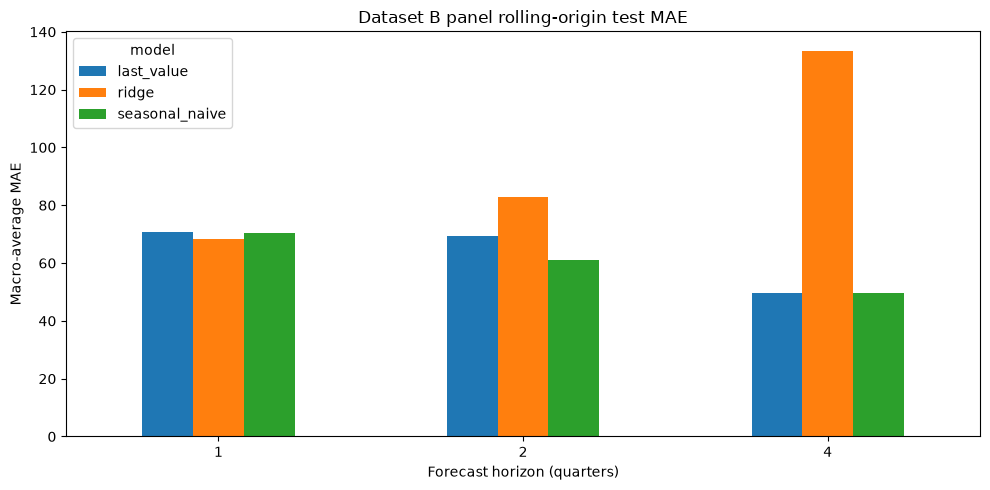

In [20]:
test_mae = summary[summary["split"] == "test"].pivot(index="horizon_q", columns="model", values="MAE")
ax = test_mae.plot(kind="bar", figsize=(10, 5))
ax.set(title="Dataset B panel rolling-origin test MAE", xlabel="Forecast horizon (quarters)", ylabel="Macro-average MAE")
ax.tick_params(axis="x", rotation=0)
ax.figure.tight_layout()
ax.figure.savefig(FIGURES / "04_test_mae_by_horizon.png", dpi=150, bbox_inches="tight")
plt.show()

### How to read this figure

Each group of bars is one forecast horizon: one, two, or four quarters ahead. Each colored bar is a baseline model, and a shorter bar means a lower test MAE and therefore a better average forecast. Compare models within the same horizon; do not compare bar heights across horizons as if they were the same forecasting task. This chart is a quick visual summary, while `baselines.csv` contains the complete MAE, RMSE, MASE, and sMAPE results.